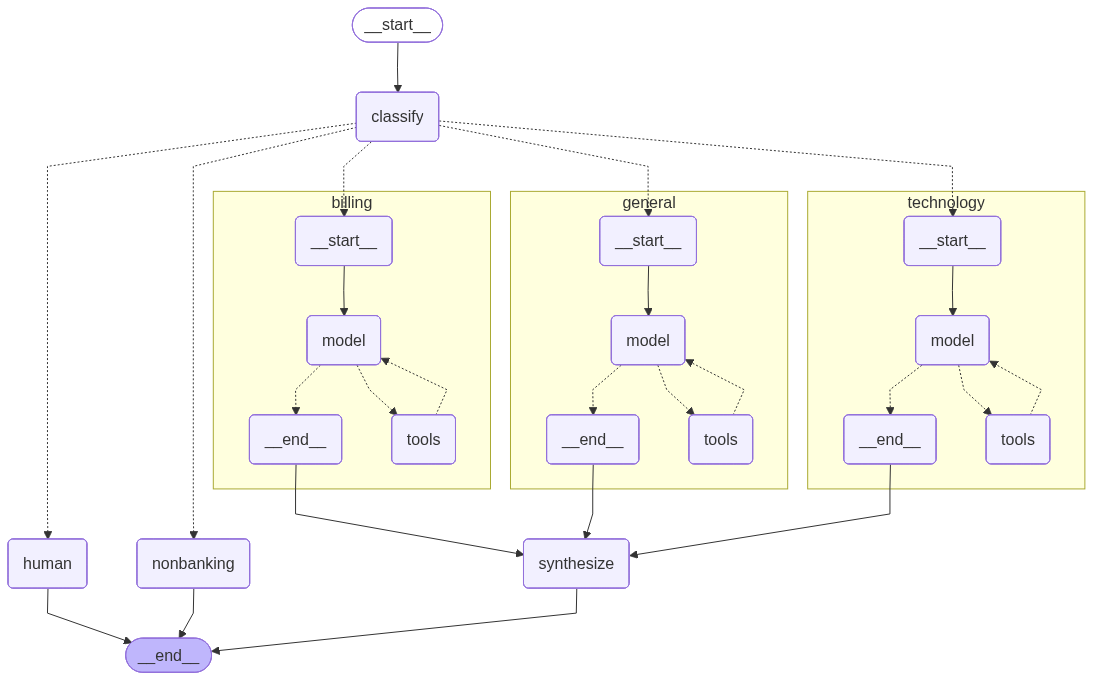

TypeError: Type is not msgpack serializable: function

In [ ]:
"""
Multi-Source Knowledge Router Example

This example demonstrates the router pattern for multi-agent systems.
A router classifies queries, routes them to specialized agents in parallel,
and synthesizes results into a combined response.
"""

import operator
from typing import Annotated, Literal, TypedDict

from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Send, Command
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import InMemorySaver

# State definitions
class AgentInput(TypedDict):
    """Simple input state for each subagent."""
    query: str


class AgentOutput(TypedDict):
    """Output from each subagent."""
    source: str
    result: str


class Classification(TypedDict):
    """A single routing decision: which agent to call with what query."""
    source: Literal["general", "technology", "billing", "nonbanking", "human"]
    query: str


class RouterState(TypedDict):
    query: str
    classifications: list[Classification]
    results: Annotated[list[AgentOutput], operator.add]
    final_answer: str


# Structured output schema for classifier
class ClassificationResult(BaseModel):
    """Result of classifying a user query into agent-specific sub-questions."""
    classifications: list[Classification] = Field(
        description="List of agents to invoke with their targeted sub-questions"
    )


# Tools
@tool
def search_general(query: str, repo: str = "main") -> str:
    """Search general questions."""
    return f"Found code matching '{query}' in {repo}: authentication middleware in src/auth.py"



@tool
def search_technology(query: str) -> str:
    """Search technology workspace for documentation."""
    return f"Found documentation: 'API Authentication Guide' - covers OAuth2 flow, API keys, and JWT tokens"


@tool
def search_billing(query: str) -> str:
    """Search billing messages and threads."""
    return f"Found discussion in #engineering: 'Use Bearer tokens for API auth, see docs for refresh flow'"

# Models and agents
model = init_chat_model("openai:gpt-5.5")
router_llm = init_chat_model("openai:gpt-5.4-mini")

general_agent = create_agent(
    model,
    tools=[search_general],
    system_prompt=(
        "You are a general expert."
    ),
)

technology_agent = create_agent(
    model,
    tools=[search_technology],
    system_prompt=(
        "You are a technology expert."
    ),
)

billing_agent = create_agent(
    model,
    tools=[search_billing],
    system_prompt=(
        "You are a billing expert."
    ),
)


# Workflow nodes
def classify_query(state: RouterState) -> dict:
    """Classify query and determine which agents to invoke."""
    structured_llm = router_llm.with_structured_output(ClassificationResult)

    result = structured_llm.invoke([
        {
            "role": "system",
            "content": """Analyze this query and determine which knowledge bases to consult.
ONLY use one of the following:

Available:
- nonbaking: Any query NOT related to banking MUST go to nonbaking
- technology: Banking Technology questions related to such things as the app, mobile, etc.
- billing: Banking Billing questions such as bills
- general: Banking General questions, NOT related to technology or billing
- human: Banking question requiring a human to approve, such as deposits and withdrawls

Return ONLY the sources that are relevant to the query."""
        },
        {"role": "user", "content": state["query"]}
    ])

    return {"classifications": result.classifications}


def route_to_agents(state: RouterState) -> list[Send]:
    """Fan out to agents based on classifications."""
    return [
        Send(c["source"], {"query": c["query"]})
        for c in state["classifications"]
    ]

def handle_nonbanking(state: AgentInput) -> dict:
    """Handle non-banking related requests"""
    return {"final_answer": "Come on, let's stick with banking questions."}

def handle_human(state: AgentInput) -> dict:
    """Handle queries requiring a human approval"""
    is_approved = interrupt({
            "query": state["query"]
    })

    if is_approved:
        return {"final_answer": "YES!  The human has APPROVED your request!"}
    else:
        return {"final_answer": "Sorry, the human has denied your request."}



def query_general(state: AgentInput) -> dict:
    """Query the general agent."""
    result = general_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "general", "result": result["messages"][-1].content}]}


def query_technology(state: AgentInput) -> dict:
    """Query the technology agent."""
    result = technology_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "technology", "result": result["messages"][-1].content}]}


def query_billing(state: AgentInput) -> dict:
    """Query the billing agent."""
    result = billing_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "billing", "result": result["messages"][-1].content}]}


def synthesize_results(state: RouterState) -> dict:
    """Combine results from all agents into a coherent answer."""
    if not state["results"]:
        return {"final_answer": "No results found from any knowledge source."}

    formatted = [
        f"**From {r['source'].title()}:**\n{r['result']}"
        for r in state["results"]
    ]

    synthesis_response = router_llm.invoke([
        {
            "role": "system",
            "content": f"""Synthesize these search results to answer the original question: "{state['query']}"

- Combine information from multiple sources without redundancy
- Highlight the most relevant and actionable information
- Note any discrepancies between sources
- Keep the response concise and well-organized"""
        },
        {"role": "user", "content": "\n\n".join(formatted)}
    ])

    return {"final_answer": synthesis_response.content}


# Build workflow
workflow = (
    StateGraph(RouterState)
    .add_node("classify", classify_query)
    .add_node("general", query_general)
    .add_node("nonbanking", handle_nonbanking)
    .add_node("human", handle_human)
    .add_node("technology", query_technology)
    .add_node("billing", query_billing)
    .add_node("synthesize", synthesize_results)
    .add_edge(START, "classify")
    .add_conditional_edges("classify", route_to_agents, ["general", "technology", "billing", "nonbanking", "human"])
    .add_edge("nonbanking", END)
    .add_edge("human", END)
    .add_edge("general", "synthesize")
    .add_edge("technology", "synthesize")
    .add_edge("billing", "synthesize")
    .add_edge("synthesize", END)
    .compile(checkpointer=InMemorySaver())
)

config = {"configurable": {"thread_id": "1"}}

if __name__ == "__main__":
    from IPython.display import Image, display
    display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))
    query = input("What would you like me to answer?")
    result = workflow.invoke({
        "query": query
    }, config=config)

    if "__interrupt__" in result:
        current_interrupt = result["__interrupt__"][0]
        human_input = input("[HUMAN] {current_interrupt.value['query']} - DO YOU APPROVE? (yes/no)? ").lower()
        human_choice = human_input in ["yes", "y"]
        result = workflow.invoke(Command(resume=human_choice), config=config)

    print("Original query:", result["query"])
    print("\nClassifications:")
    for c in result["classifications"]:
        print(f"  {c['source']}: {c['query']}")
    print("\n" + "=" * 60 + "\n")
    print("Final Answer:")
    print(result["final_answer"])